In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, recall_score, precision_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

In [2]:
Ytrain  = pd.read_pickle('../data/ytrain.pkl')
Ytest   = pd.read_pickle('../data/ytest.pkl')

Xtrain  = pd.read_pickle('../data/xtrain.pkl')
Xtest   = pd.read_pickle('../data/xtest.pkl')

In [4]:
rf = RandomForestClassifier(n_estimators= 100, criterion='entropy')

In [5]:
rf.fit(Xtrain, Ytrain)

RandomForestClassifier(criterion='entropy')

In [ ]:
print(cross_val_score(rf, Xtrain, Ytrain, cv = 5))

[0.95039164 0.92689295 0.92950392 0.93455497 0.95811518]


In [18]:
print(cross_val_score(rf, Xtrain, Ytrain, cv = 5).mean())

0.9398903667655463


In [9]:
ypred = rf.predict(Xtest)

In [10]:
conf_mat = confusion_matrix(Ytest, ypred, labels=[1, 2, 3])

(213,)

In [25]:
conf_mat

array([[154,   5,   0],
       [  4,  32,   0],
       [  0,   1,  17]])

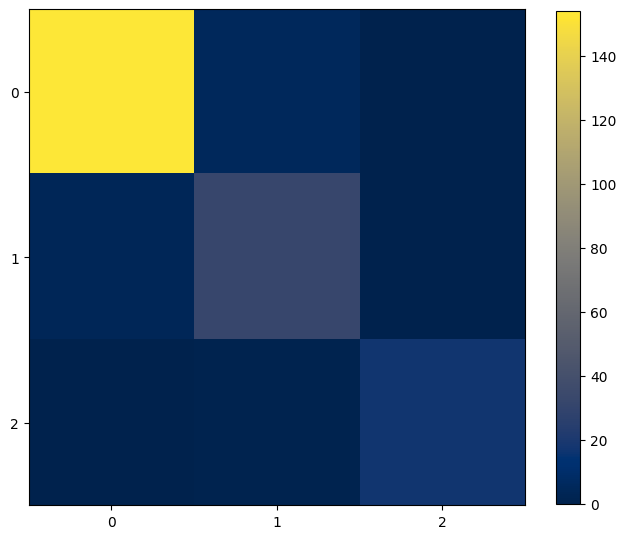

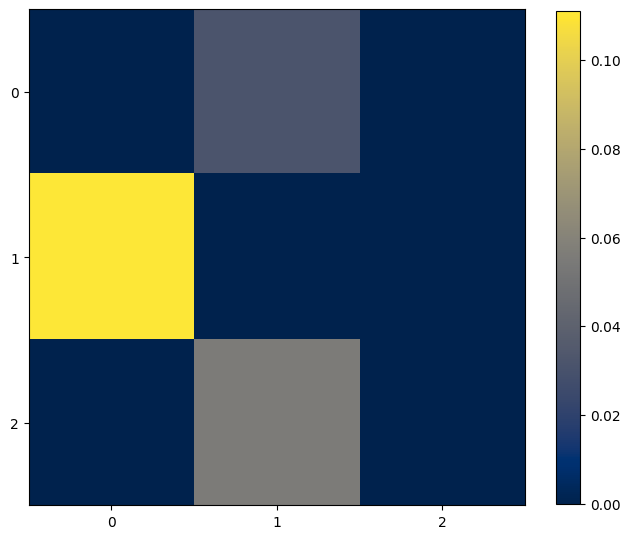

In [24]:

plt.figure(figsize=(8, 8))
plt.imshow(conf_mat, cmap='cividis')
plt.xticks(ticks=[0,1,2])
plt.yticks(ticks=[0,1,2])
plt.colorbar(shrink = 0.8)
plt.savefig('../results/ConMatrixRandomForest.png')
plt.show()


conf_matrix_relative = conf_mat.copy()
np.fill_diagonal(conf_matrix_relative, val = 0)
conf_matrix_relative = conf_matrix_relative/ conf_mat.sum(axis = 1, keepdims=True)

plt.figure(figsize=(8, 8))
plt.xticks(ticks=[0,1,2])
plt.yticks(ticks=[0,1,2])
plt.imshow(conf_matrix_relative, cmap='cividis')
plt.colorbar(shrink = 0.8)
plt.savefig('../results/relativeConMatrixRandomForest.png')
plt.show()


In [28]:
print(classification_report(Ytest, ypred).replace("      ", "&"))

&&  precision    recall  f1-score   support

&     1& 0.97&0.97&0.97& 159
&     2& 0.84&0.89&0.86&  36
&     3& 1.00&0.94&0.97&  18

    accuracy&&&&   0.95& 213
   macro avg& 0.94&0.93&0.94& 213
weighted avg& 0.95&0.95&0.95& 213

